# MODELO KMEANS PARA CLASIFICACIÓN DE CLIENTES
## FUENTE : [KAGGLE](https://www.kaggle.com/datasets/dev0914sharma/customer-clustering?resource=download)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("dev0914sharma/customer-clustering")

print("Path to dataset files:", path)

100%|██████████| 25.9k/25.9k [00:00<00:00, 25.2MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/dev0914sharma/customer-clustering/versions/1


In [3]:
!ls /root/.cache/kagglehub/datasets/dev0914sharma/customer-clustering/versions/1

'segmentation data.csv'  'segmentation data legend.xlsx'


In [4]:
PATH_CSV = path + '/segmentation data.csv'

In [5]:
df = pd.read_csv(PATH_CSV)
df

,ID,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
0,100000001,0,0,67,2,124670,1,2
1,100000002,1,1,22,1,150773,1,2
2,100000003,0,0,49,1,89210,0,0
3,100000004,0,0,45,1,171565,1,1
4,100000005,0,0,53,1,149031,1,1
...,...,...,...,...,...,...,...,...
1995,100001996,1,0,47,1,123525,0,0
1996,100001997,1,1,27,1,117744,1,0
1997,100001998,0,0,31,0,86400,0,0
1998,100001999,1,1,24,1,97968,0,0


In [6]:
df.dtypes

,0
ID,int64
Sex,int64
Marital status,int64
Age,int64
Education,int64
Income,int64
Occupation,int64
Settlement size,int64


In [7]:
df.isnull().sum().sum()

np.int64(0)

In [8]:
df.drop(columns=['ID'],inplace=True)
df.head(5)

,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
0,0,0,67,2,124670,1,2
1,1,1,22,1,150773,1,2
2,0,0,49,1,89210,0,0
3,0,0,45,1,171565,1,1
4,0,0,53,1,149031,1,1


# BUSCAMOS OUTLIERS


In [9]:
from scipy.stats import zscore

z_scores = df.apply(zscore)

outliers = (z_scores.abs() > 3).sum()

outliers

,0
Sex,0
Marital status,0
Age,11
Education,36
Income,31
Occupation,0
Settlement size,0


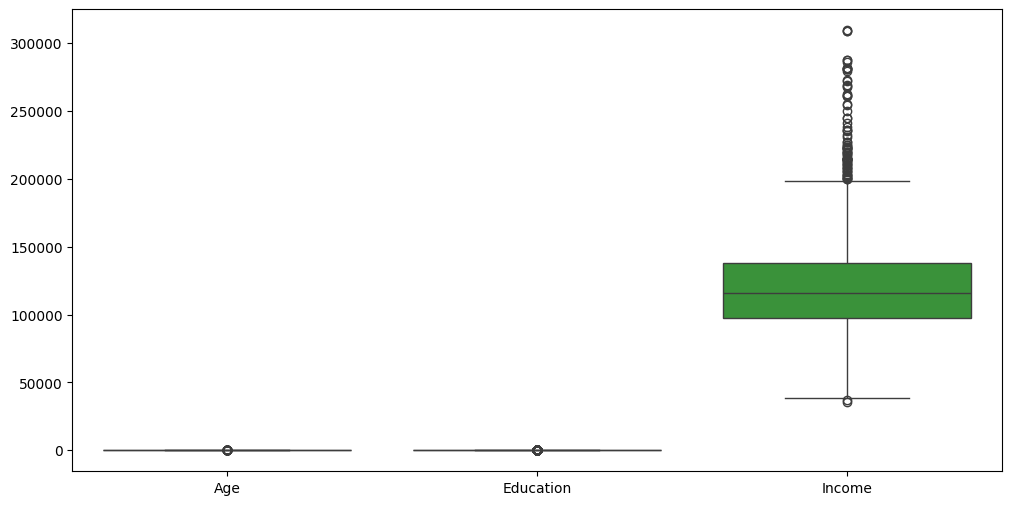

In [10]:
plt.figure(figsize=(12,6))

sns.boxplot(data=df[['Age','Education','Income']])
plt.show()

In [11]:
df_cleaned = df[
    (z_scores['Age'].abs() <= 3) &
    (z_scores['Education'].abs() <= 3) &
    (z_scores['Income'].abs() <= 3)
].copy()
df_cleaned

,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
0,0,0,67,2,124670,1,2
1,1,1,22,1,150773,1,2
2,0,0,49,1,89210,0,0
3,0,0,45,1,171565,1,1
4,0,0,53,1,149031,1,1
...,...,...,...,...,...,...,...
1995,1,0,47,1,123525,0,0
1996,1,1,27,1,117744,1,0
1997,0,0,31,0,86400,0,0
1998,1,1,24,1,97968,0,0


# APLICAMOS AC

In [12]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import dendrogram

In [22]:
from sklearn.preprocessing import MinMaxScaler

In [23]:
X = df_cleaned.select_dtypes(include=[np.number])
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [13]:
X = df_cleaned.select_dtypes(include=[np.number])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [25]:
model = AgglomerativeClustering(
    n_clusters=14,
    linkage="ward"
)

In [26]:
labels = model.fit_predict(X_scaled)

In [27]:
df_cleaned["cluster"] = labels

In [28]:
df_cleaned['cluster'].value_counts()

,count
cluster,
0,235
1,229
3,224
2,176
4,166
8,158
13,144
5,113
12,103


In [29]:
sil = silhouette_score(X_scaled, labels)
print("Silhouette Score:", round(sil, 3))

Silhouette Score: 0.485


In [21]:
agg = AgglomerativeClustering(
    n_clusters=None,
    linkage="average",
    metric="euclidean",
    distance_threshold=1.0  # Añadir un valor para distance_threshold
)

labels = agg.fit_predict(X_scaled)

n_clusters_found = len(np.unique(labels))

print(f'Número de clusters encontrados: {n_clusters_found}')

if n_clusters_found > 1:
    silhouette_value = silhouette_score(X_scaled, labels)
    print(f'Silhouette Score: {silhouette_value:.4f}')

Número de clusters encontrados: 181
Silhouette Score: 0.4447


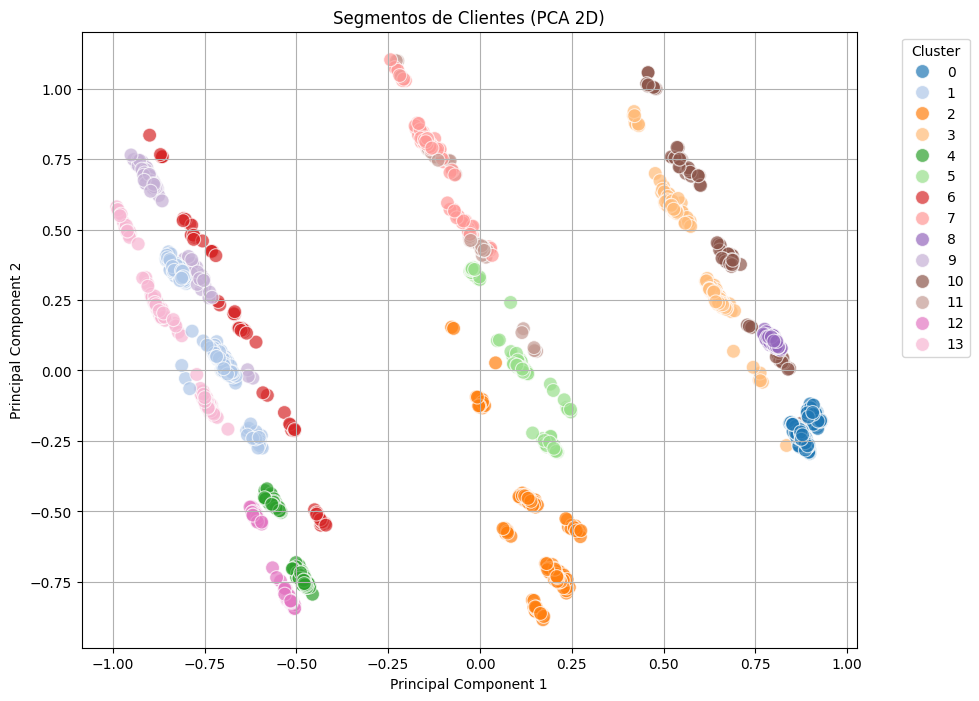

In [30]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
df_pca['cluster'] = df_cleaned['cluster'].reset_index(drop=True)

plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC1', y='PC2', hue='cluster', data=df_pca, palette='tab20', s=100, alpha=0.7)
plt.title('Segmentos de Clientes (PCA 2D)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()